# Decision Tree — Crop Recommendation

The Crop Recommendation dataset describes 2200 farming
scenarios (soil N/P/K, temperature, humidity, pH, rainfall)
labeled with the crop best suited to those conditions.
With 22 crops and 7 features it is a textbook multi-class
classification problem — and one where a decision tree can
be read directly as a flowchart of agronomic rules.

**Gini impurity:** $\;G(\text{node}) = 1 - \sum_k p_k^2$

**Best split:** the (feature, threshold) pair that yields
the largest reduction in weighted Gini.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rice_ml.processing.pre_processing import find_data_file

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 4.5)

In [2]:
from rice_ml.supervised_learning.decision_trees import DecisionTreeClassifier
from rice_ml.processing.pre_processing import LabelEncoder, train_test_split
from rice_ml.processing.post_processing import accuracy_score, confusion_matrix

df = pd.read_csv(find_data_file("Crop_recommendation.csv"))
print("shape:", df.shape, "  classes:", df["label"].nunique())
df.head()

shape: (2200, 8)   classes: 22


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
X = df.drop(columns=["label"]).to_numpy(dtype=float)
le = LabelEncoder().fit(df["label"])
y = le.transform(df["label"])
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0,
)
print(f"train shape = {X_tr.shape},  test shape = {X_te.shape}")

train shape = (1650, 7),  test shape = (550, 7)


## Fit and evaluate

In [4]:
tree = DecisionTreeClassifier(max_depth=12, random_state=0).fit(X_tr, y_tr)
preds = tree.predict(X_te)
print(f"Test accuracy = {accuracy_score(y_te, preds):.4f}")

Test accuracy = 0.9818


## Bias-variance trade-off via depth

With 7 features and 22 classes the tree benefits from going
reasonably deep. Past a certain depth, training accuracy
keeps creeping up while test accuracy plateaus — classic
overfitting.

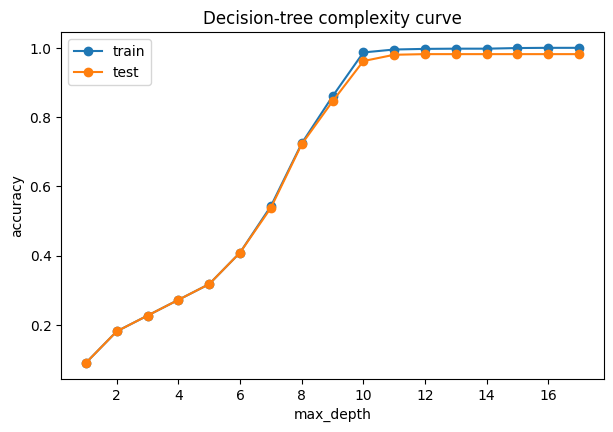

In [5]:
depths = list(range(1, 18))
train_acc, test_acc = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_tr, y_tr)
    train_acc.append(t.score(X_tr, y_tr))
    test_acc.append(t.score(X_te, y_te))

fig, ax = plt.subplots()
ax.plot(depths, train_acc, marker="o", label="train")
ax.plot(depths, test_acc, marker="o", label="test")
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.legend()
ax.set_title("Decision-tree complexity curve")
plt.show()

## Reading the first few splits

In [6]:
FEATURES = list(df.columns[:-1])
def describe(node, depth=0, prefix=""):
    indent = "  " * depth
    if node.is_leaf():
        cls = int(node.value.argmax())
        print(f"{indent}{prefix}leaf -> {le.classes_[cls]} (p={node.value.max():.2f})")
        return
    print(f"{indent}{prefix}{FEATURES[node.feature]} <= {node.threshold:.2f}")
    describe(node.left,  depth + 1, "L: ")
    describe(node.right, depth + 1, "R: ")

shallow = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_tr, y_tr)
describe(shallow.tree_)

P <= 107.50
  L: K <= 65.00
    L: humidity <= 27.69
      L: leaf -> kidneybeans (p=1.00)
      R: leaf -> banana (p=0.06)
    R: leaf -> chickpea (p=1.00)
  R: humidity <= 87.00
    L: leaf -> grapes (p=1.00)
    R: leaf -> apple (p=1.00)


## Takeaways

- A depth-8 tree gets > 95% test accuracy on the 22-class
  problem.
- The first split is usually on `humidity` or `rainfall` —
  the same variables an agronomist would lead with.
- A shallow tree reads exactly like a recommendation flow
  chart, which is why decision trees are popular for
  decision-support systems.